In [1]:
import polars as pl 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pl.scan_parquet('/home/ma/a/alb25/Project/thesis_code/data/processed/train_df.parquet')

In [3]:
df.head().collect()

time,source_user@domain,destination_user@domain,source_computer,destination_computer,authentication_type,logon_type,authentication_orientation,source_user_type,destination_user_type,success
duration[μs],str,str,str,str,enum,enum,enum,enum,enum,bool
6d 8h 13m 45s,"""ANONYMOUS LOGON@C1""","""ANONYMOUS LOGON@C1""","""C12889""","""C1""","""NTLM""","""Network""","""LogOn""","""anon""","""anon""",true
6d 8h 13m 45s,"""ANONYMOUS LOGON@C1""","""ANONYMOUS LOGON@C1""","""C1""","""C1""","""?""","""Network""","""LogOff""","""anon""","""anon""",true
12d 8h 33m 10s,"""ANONYMOUS LOGON@C1""","""ANONYMOUS LOGON@C1""","""C1""","""C1""","""NTLM""","""Network""","""LogOn""","""anon""","""anon""",true
16d 13h 57m 28s,"""ANONYMOUS LOGON@C1""","""ANONYMOUS LOGON@C1""","""C1""","""C1""","""?""","""Network""","""LogOff""","""anon""","""anon""",true
16d 13h 57m 28s,"""ANONYMOUS LOGON@C1""","""ANONYMOUS LOGON@C1""","""C1191""","""C1""","""NTLM""","""Network""","""LogOn""","""anon""","""anon""",true


### Simple time series of training data

##### Daily

In [35]:
df2 = df.with_columns(pl.col('time').dt.total_days().alias('days')).select('days')
auth_per_day = df2.group_by('days').len().collect()
auth_per_day = auth_per_day.sort(by='days')

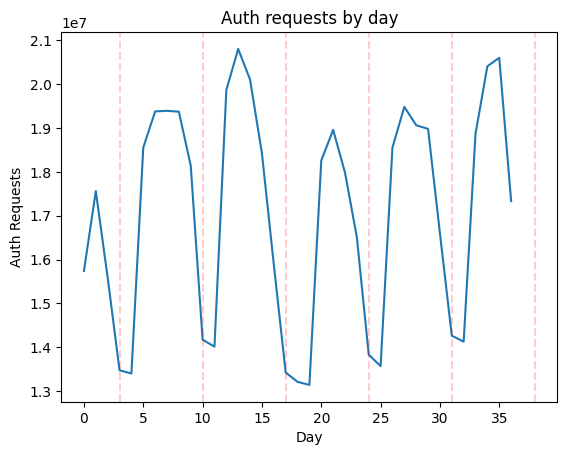

In [37]:
plt.plot(
    auth_per_day['days'].to_list(),
    auth_per_day['len'].to_list())
plt.title('Auth requests by day')
plt.xlabel('Day')
plt.ylabel('Auth Requests')
for i in range(6):
    plt.axvline(3 + 7*i, color='red', alpha=0.2, linestyle='--')
plt.show()

In [20]:
24*60/15

96.0

##### Hourly

In [37]:
block_size = 4
num_blocks = (24*60//block_size)
step_blocks = 2 * 60 // block_size

df2 = df.with_columns(((pl.col('time').dt.total_minutes() // block_size) % num_blocks).alias('block')).select('block')
auth_per_block = df2.group_by('block').len().collect()
auth_per_block = auth_per_block.sort(by='block')

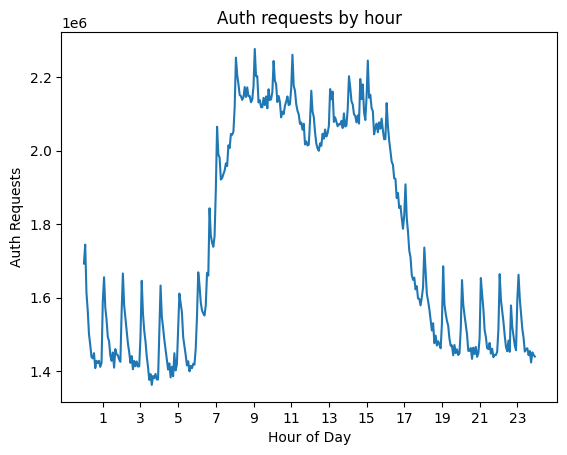

In [38]:
plt.plot(
    auth_per_block['block'].to_list(),
    auth_per_block['len'].to_list())
plt.title('Auth requests by hour')
plt.xlabel('Hour of Day')
plt.ylabel('Auth Requests')
plt.xticks(np.arange(60 // block_size, num_blocks, step_blocks), np.arange(1, 24, 2))
# for i in range(6):
#     plt.axvline(color='red', alpha=0.2, linestyle='--')
plt.show()

##### Auth requests per minute of hour for both human and machine accounts

In [52]:
human_df = df.filter(pl.col('source_user_type') == 'human')
machine_df = df.filter(pl.col('source_user_type') == 'machine')
system_df = df.filter(pl.col('source_user_type') == 'system')

def minute_counts(d):
    d = d.with_columns((pl.col('time').dt.total_minutes() % (24*60)).alias('minute'))
    d = d.group_by('minute').len()
    d = d.sort(by='minute')
    d = d.collect()
    return d.select('minute').to_series().to_list(), d.select('len').to_series().to_list()

mins, human_counts = minute_counts(human_df)
_, machine_counts = minute_counts(machine_df)
_, system_counts = minute_counts(system_df)

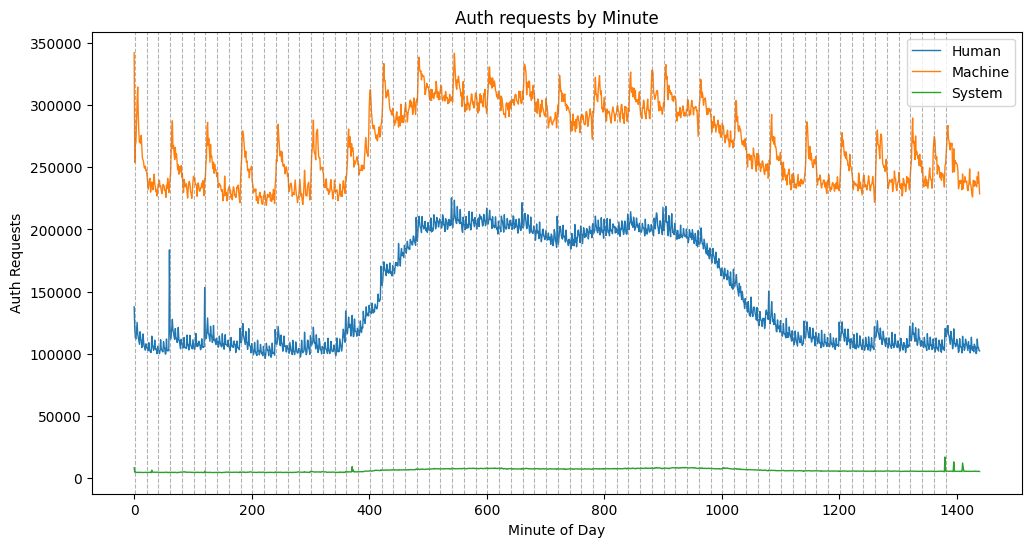

In [67]:
plt.figure(figsize=(12, 6))
plt.plot(mins, human_counts, linewidth=1, label='Human')
plt.plot(mins, machine_counts, linewidth=1, label='Machine')
plt.plot(mins, system_counts, linewidth=1, label='System')
plt.title('Auth requests by Minute')
plt.xlabel('Minute of Day')
plt.ylabel('Auth Requests')
for x in range(0, 1400, 20):
    plt.axvline(x+1, color="grey", linewidth=0.8, alpha=0.6, linestyle='--')
plt.legend()
plt.show()

In [57]:
def minute_of_hour_counts(d):
    d = d.with_columns((pl.col('time').dt.total_minutes() % 60).alias('minute'))  # only change
    d = d.group_by('minute').len()
    d = d.sort(by='minute')
    d = d.collect()
    return d.select('minute').to_series().to_list(), d.select('len').to_series().to_list()

minute, human_counts_ = minute_of_hour_counts(human_df)
_, machine_counts_ = minute_of_hour_counts(machine_df)
_, system_counts_ = minute_of_hour_counts(system_df)

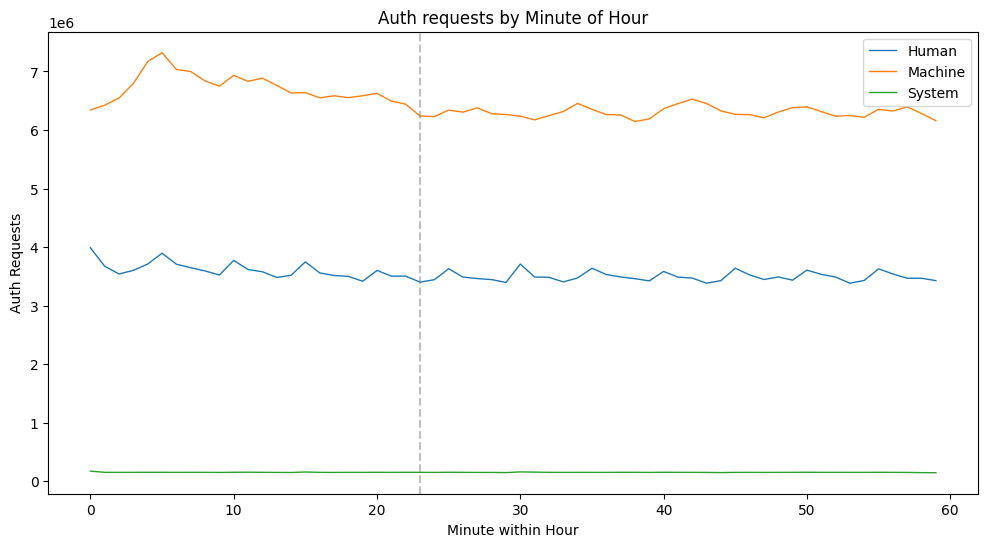

In [75]:
plt.figure(figsize=(12, 6))
plt.plot(minute, human_counts_, linewidth=1, label='Human')
plt.plot(minute, machine_counts_, linewidth=1, label='Machine')
plt.plot(minute, system_counts_, linewidth=1, label='System')
plt.title('Auth requests by Minute of Hour')
plt.xlabel('Minute within Hour')
plt.ylabel('Auth Requests')
plt.axvline(23, linestyle='--', color='grey', alpha=0.5)
plt.legend()
plt.show()

### Investigating bin size

All bins to investigate should be divisible by 24 to capture the strong diurnal patterns in the data.

Check 15 min bins 60 min bins and 5 min bins. A lot of machine users have hourly patterns? Investigate this

Find a trade off to optimise. Note that the trade off may be different for the clustered approach to the regular approach as we have a different bias variance trade off to optimise.

# Notes

- Interval width has its own 'smoothing effect'